<a href="https://colab.research.google.com/github/vishnupriyaE553/Seasonal-Agriculture-Performance-Analysis/blob/main/Seasonal_Agriculture_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Dataset**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset.csv


# **Initial Data Understanding**

In [ ]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully!
Number of rows: 4000
Number of columns: 28


# **Data Quality Analysis**

In [ ]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [ ]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [ ]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
print("States:")
print(df["State"].value_counts())

print("\nCrops:")
print(df["Crop"].value_counts())

print("\nSeasons:")
print(df["Season"].value_counts())

print("\nIrrigation Methods:")
print(df["Irrigation_Method"].value_counts())

States:
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

Crops:
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

Seasons:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Irrigation Methods:
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [ ]:
# Check missing values before treatment
print("Missing values before treatment:")
print(df[["Rainfall_mm", "Soil_Moisture_pct", "Yield_Tonnes_Ha"]].isnull().sum())

Missing values before treatment:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64


In [ ]:
# Fill missing values using the median
df["Rainfall_mm"] = df["Rainfall_mm"].fillna(df["Rainfall_mm"].median())
df["Soil_Moisture_pct"] = df["Soil_Moisture_pct"].fillna(df["Soil_Moisture_pct"].median())
df["Yield_Tonnes_Ha"] = df["Yield_Tonnes_Ha"].fillna(df["Yield_Tonnes_Ha"].median())

In [ ]:
print("Missing values after treatment:")
print(df[["Rainfall_mm", "Soil_Moisture_pct", "Yield_Tonnes_Ha"]].isnull().sum())

Missing values after treatment:
Rainfall_mm          0
Soil_Moisture_pct    0
Yield_Tonnes_Ha      0
dtype: int64


# **Season distribution**

In [ ]:
season_counts = df["Season"].value_counts()
print(season_counts)

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


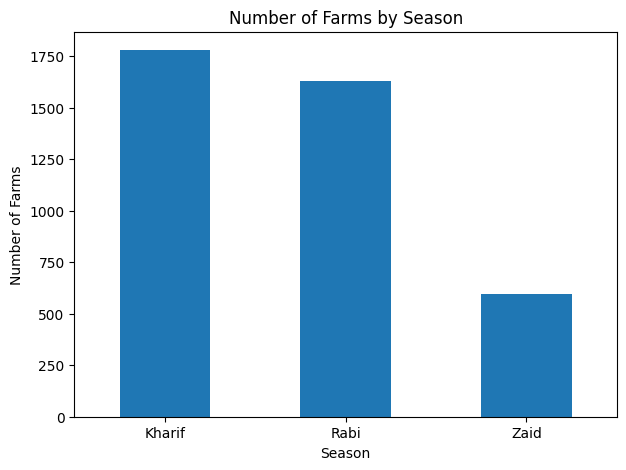

In [ ]:
plt.figure(figsize=(7,5))
season_counts.plot(kind="bar")
plt.title("Number of Farms by Season")
plt.xlabel("Season")
plt.ylabel("Number of Farms")
plt.xticks(rotation=0)
plt.show()

# **Crop Distribution**

In [ ]:
crop_counts = df["Crop"].value_counts()
print(crop_counts)

Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64


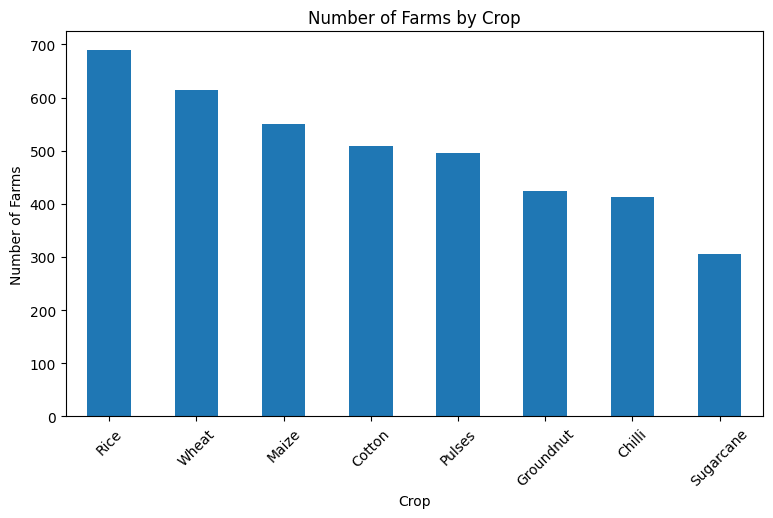

In [ ]:
plt.figure(figsize=(9,5))
crop_counts.plot(kind="bar")
plt.title("Number of Farms by Crop")
plt.xlabel("Crop")
plt.ylabel("Number of Farms")
plt.xticks(rotation=45)
plt.show()

# **Univariate Analysis**
Univariate analysis examines one variable at a time.

# **Distribution of Yield**

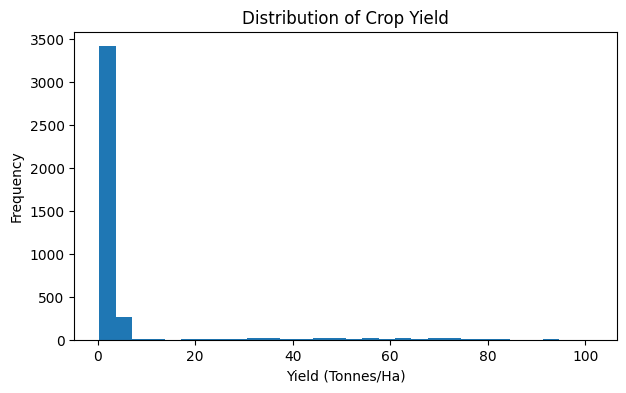

In [ ]:
plt.figure(figsize=(7,4))

plt.hist(df["Yield_Tonnes_Ha"], bins=30)

plt.title("Distribution of Crop Yield")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Frequency")

plt.show()

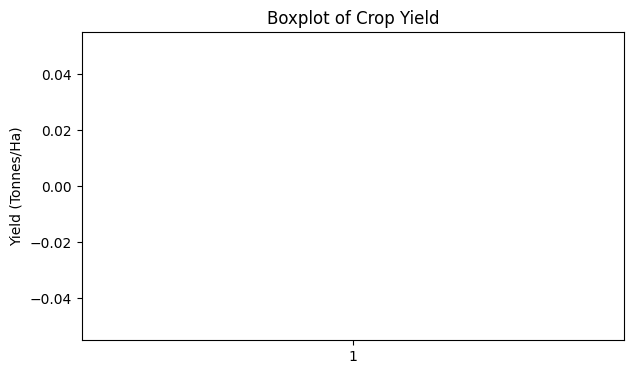

In [ ]:
plt.figure(figsize=(7,4))
plt.boxplot(df["Yield_Tonnes_Ha"])
plt.title("Boxplot of Crop Yield")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

# **Distribution of Profit**

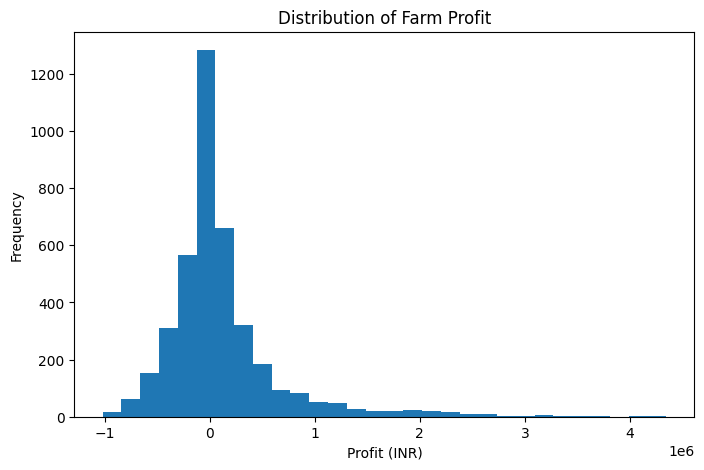

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df["Profit_INR"], bins=30)
plt.title("Distribution of Farm Profit")
plt.xlabel("Profit (INR)")
plt.ylabel("Frequency")
plt.show()

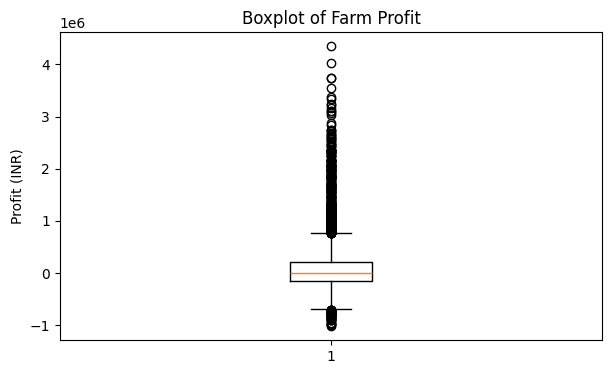

In [ ]:
plt.figure(figsize=(7,4))
plt.boxplot(df["Profit_INR"])
plt.title("Boxplot of Farm Profit")
plt.ylabel("Profit (INR)")
plt.show()

# **Distribution of Water Usage**

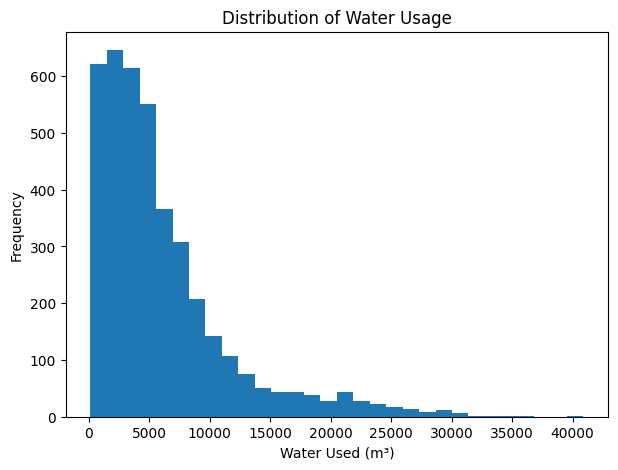

In [ ]:
plt.figure(figsize=(7,5))
plt.hist(df["Water_Used_m3"], bins=30)
plt.title("Distribution of Water Usage")
plt.xlabel("Water Used (m³)")
plt.ylabel("Frequency")
plt.show()

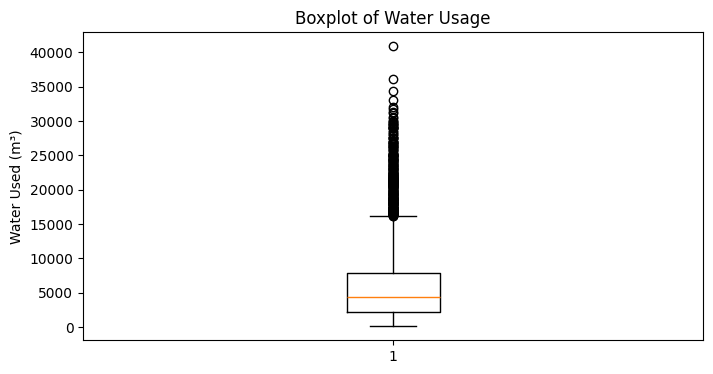

In [ ]:
plt.figure(figsize=(8,4))
plt.boxplot(df["Water_Used_m3"])
plt.title("Boxplot of Water Usage")
plt.ylabel("Water Used (m³)")
plt.show()

# **Outlier Analysis using the IQR method**

Interquartile Range (IQR) method

The formula is: IQR = Q3 − Q1

In [ ]:
# Function to detect outliers using IQR

def detect_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print("Column:", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of potential outliers:", len(outliers))
    print()

In [ ]:
detect_outliers("Yield_Tonnes_Ha")
detect_outliers("Profit_INR")
detect_outliers("Water_Used_m3")

Column: Yield_Tonnes_Ha
Q1: 1.05
Q3: 2.84
IQR: 1.7899999999999998
Lower Bound: -1.6349999999999996
Upper Bound: 5.5249999999999995
Number of potential outliers: 302

Column: Profit_INR
Q1: -148731.75
Q3: 216187.75
IQR: 364919.5
Lower Bound: -696111.0
Upper Bound: 763567.0
Number of potential outliers: 404

Column: Water_Used_m3
Q1: 2268.75
Q3: 7829.75
IQR: 5561.0
Lower Bound: -6072.75
Upper Bound: 16171.25
Number of potential outliers: 276



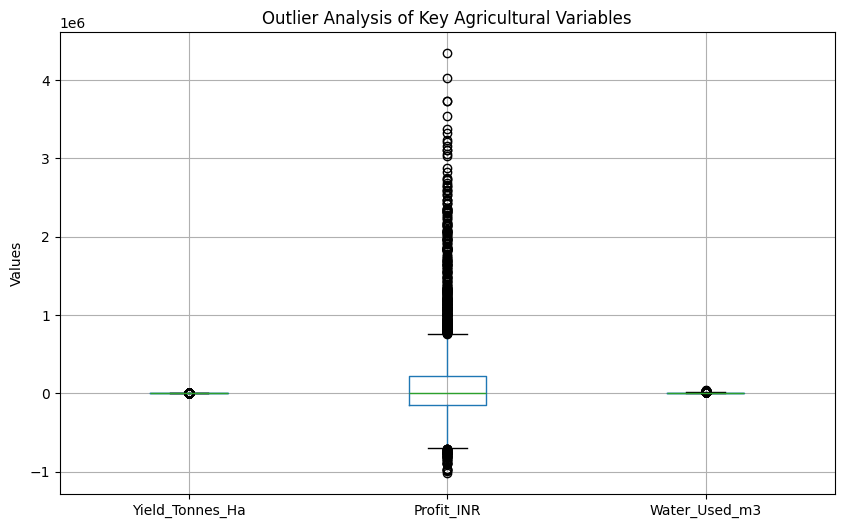

In [ ]:
plt.figure(figsize=(10,6))
df[["Yield_Tonnes_Ha", "Profit_INR", "Water_Used_m3"]].boxplot()
plt.title("Outlier Analysis of Key Agricultural Variables")
plt.ylabel("Values")
plt.show()

Yield: 302 observations are above the IQR upper limit of approximately 5.525 tonnes/ha. Since yield can naturally vary substantially between crops, these values should be investigated rather than automatically removed.

Profit: 404 observations fall outside the IQR limits. This is expected to some extent because farm profitability can vary greatly depending on crop, production, market price, and costs.

Water usage: 276 observations are above approximately 16,171 m³. These may represent farms with higher water requirements or larger production operations.

Outlier Analysis: The IQR method identified potential outliers in yield, profit, and water usage. These observations were retained because extreme values may represent genuine differences in crop type, farm operations, resource usage, or economic performance. Therefore, they were not removed without further investigation.

# **Bivariate Analysis 📊**

### **Does agricultural yield differ across seasons?**

In [ ]:
season_yield = df.groupby("Season")["Yield_Tonnes_Ha"].mean()
print(season_yield)

Season
Kharif    5.643973
Rabi      5.080498
Zaid      4.665942
Name: Yield_Tonnes_Ha, dtype: float64


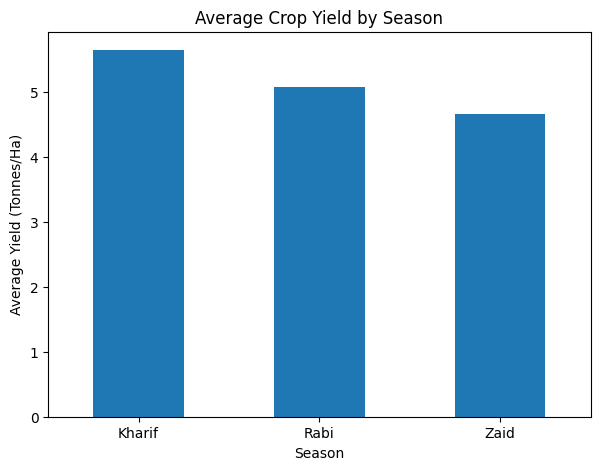

In [ ]:
plt.figure(figsize=(7,5))
season_yield.plot(kind="bar")
plt.title("Average Crop Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=0)
plt.show()

# **Irrigation Method vs Yield**

In [ ]:
irrigation_yield = df.groupby("Irrigation_Method")["Yield_Tonnes_Ha"].mean()
print(irrigation_yield)

Irrigation_Method
Drip         6.620662
Flood        4.897724
Rainfed      4.613182
Sprinkler    5.188819
Name: Yield_Tonnes_Ha, dtype: float64


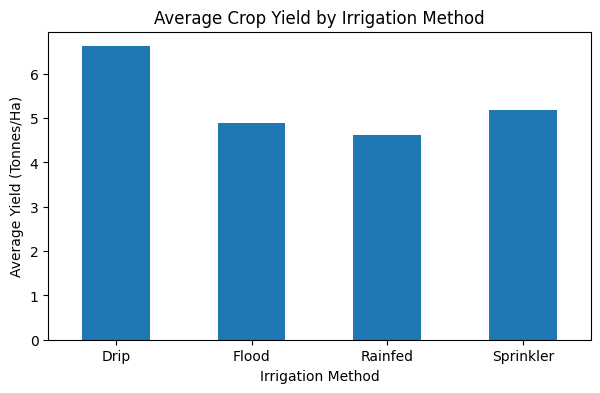

In [ ]:
plt.figure(figsize=(7,4))
irrigation_yield.plot(kind="bar")
plt.title("Average Crop Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=0)
plt.show()

# **Crop vs Yield**

In [ ]:
crop_yield = df.groupby("Crop")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

print(crop_yield)

Crop
Sugarcane    46.938746
Maize         2.717130
Rice          2.439413
Wheat         2.109216
Chilli        1.540344
Groundnut     1.317924
Cotton        1.225734
Pulses        0.918198
Name: Yield_Tonnes_Ha, dtype: float64


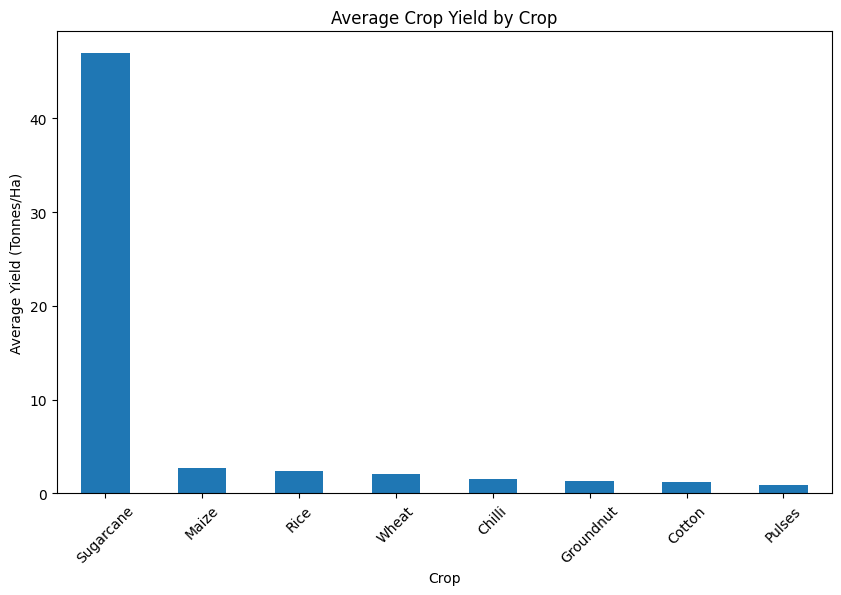

In [ ]:
plt.figure(figsize=(10,6))

crop_yield.plot(kind="bar")

plt.title("Average Crop Yield by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)

plt.show()

Sugarcane has a substantially higher average yield than the other crops in the dataset, while Pulses has the lowest average yield. The large variation between crops indicates that crop type is an important factor associated with observed yield differences.

# **Rainfall vs Yield 🌧️🌾**

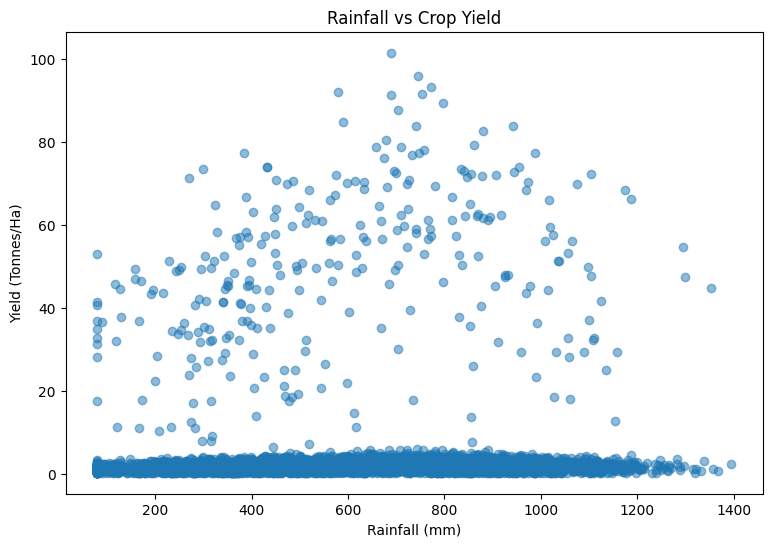

In [ ]:
plt.figure(figsize=(9,6))

plt.scatter(df["Rainfall_mm"], df["Yield_Tonnes_Ha"], alpha=0.5)

plt.title("Rainfall vs Crop Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

In [ ]:
correlation = df["Rainfall_mm"].corr(df["Yield_Tonnes_Ha"])
print("Correlation between Rainfall and Yield:", correlation)

Correlation between Rainfall and Yield: 0.03085301698272099


The Pearson correlation between rainfall and yield is approximately 0.031, indicating a very weak positive linear relationship between the two variables in this dataset. Therefore, rainfall alone does not show a meaningful linear association with yield at the overall dataset level.

# **Multivariate Analysis**
Multivariate analysis examines more than two variables together.

## **Multivariate: Season, crop and yield**

In [ ]:
season_crop_yield = df.pivot_table(
    values="Yield_Tonnes_Ha",
    index="Crop",
    columns="Season",
    aggfunc="mean"
)
print(season_crop_yield)

Season        Kharif       Rabi       Zaid
Crop                                      
Chilli      1.731413   1.461615   1.177742
Cotton      1.372804   1.192915   0.951648
Groundnut   1.483646   1.221445   1.037778
Maize       2.966410   2.614913   2.297590
Pulses      1.036063   0.871887   0.652131
Rice        2.707621   2.333680   1.900490
Sugarcane  53.459120  43.940394  38.423922
Wheat       2.255430   2.058814   1.748588


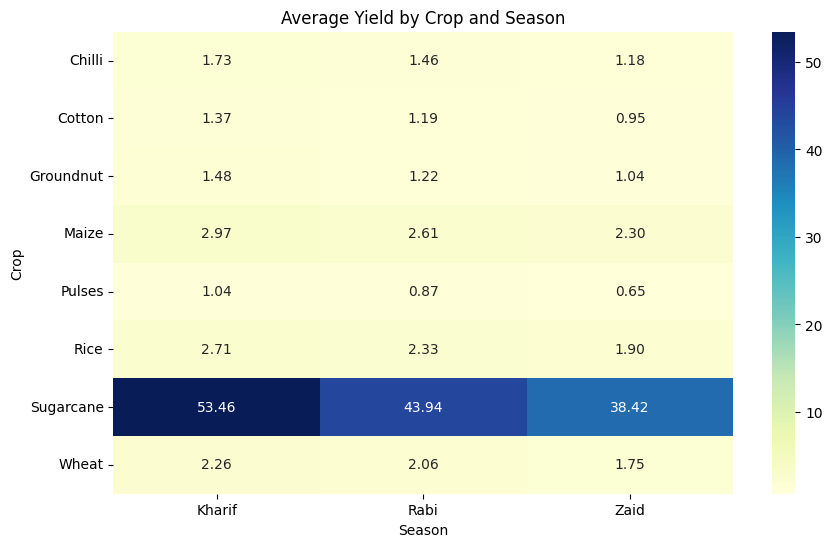

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(
    season_crop_yield,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)
plt.title("Average Yield by Crop and Season")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.show()

The heatmap indicates that average yield varies across both crop type and season. Sugarcane records the highest average yield across all seasons, while Kharif generally shows higher average yields than Rabi and Zaid for the crops in the dataset.

# **Season vs Profit**

In [ ]:
season_profit = df.groupby("Season")["Profit_INR"].mean().sort_values(ascending=False)
print(season_profit)

Season
Kharif    178914.647555
Rabi       87689.470191
Zaid      -24804.824916
Name: Profit_INR, dtype: float64


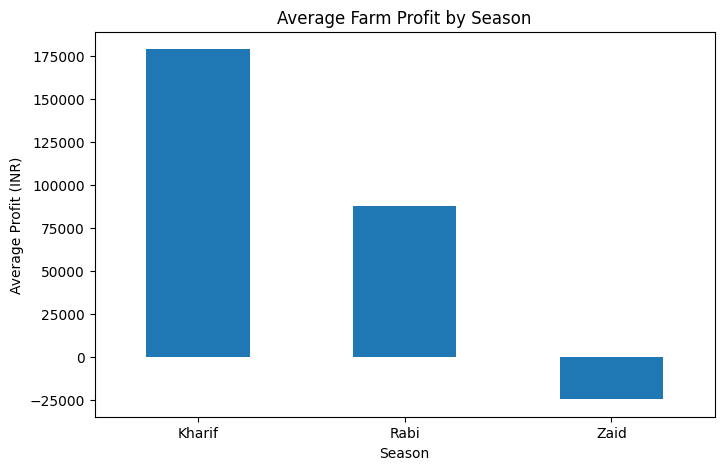

In [ ]:
plt.figure(figsize=(8,5))
season_profit.plot(kind="bar")
plt.title("Average Farm Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=0)
plt.show()

Kharif has the highest average farm profit at approximately ₹178,915, followed by Rabi at approximately ₹87,689. Zaid records a negative average profit of approximately ₹24,805, indicating that the average farm in the Zaid records operates at a loss.

# **Irrigation Method vs Profit**

In [40]:
irrigation_profit = df.groupby("Irrigation_Method")["Profit_INR"].mean().sort_values(ascending=False)
print(irrigation_profit)

Irrigation_Method
Drip         219625.997814
Sprinkler     91121.079019
Rainfed       79050.365034
Flood         73354.022901
Name: Profit_INR, dtype: float64


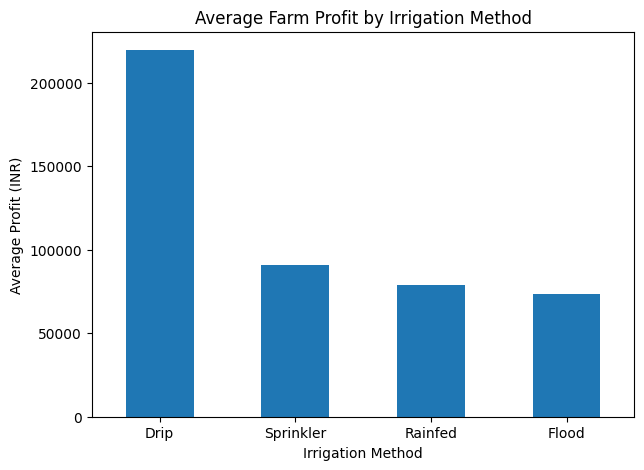

In [42]:
plt.figure(figsize=(7,5))
irrigation_profit.plot(kind="bar")
plt.title("Average Farm Profit by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=0)
plt.show()

Drip irrigation records the highest average profit among the irrigation methods at approximately ₹219,626. Sprinkler, Rainfed and Flood methods show considerably lower average profits. This indicates an association between irrigation method and farm profitability in the dataset.

# **Water Efficiency Analysis 💧**

In [43]:
irrigation_efficiency = df.groupby("Irrigation_Method")[
    "Water_Efficiency_t_per_1000m3"
].mean().sort_values(ascending=False)
print(irrigation_efficiency)

Irrigation_Method
Rainfed      7.563784
Drip         6.267129
Sprinkler    4.669805
Flood        3.438853
Name: Water_Efficiency_t_per_1000m3, dtype: float64


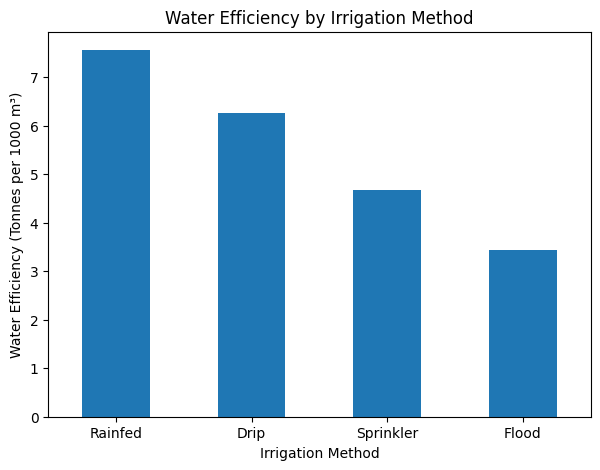

In [45]:
plt.figure(figsize=(7,5))
irrigation_efficiency.plot(kind="bar")
plt.title("Water Efficiency by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Water Efficiency (Tonnes per 1000 m³)")
plt.xticks(rotation=0)
plt.show()

Rainfed farming has the highest average water-efficiency value at approximately 7.56 tonnes per 1000 m³, followed by Drip at 6.27. Flood irrigation has the lowest average water efficiency at approximately 3.44 tonnes per 1000 m³.

# **Correlation Matrix**

In [46]:
correlation_data = df[
    [
        "Rainfall_mm",
        "Avg_Temperature_C",
        "Soil_Moisture_pct",
        "Nitrogen_kg_ha",
        "Fertilizer_kg_ha",
        "Yield_Tonnes_Ha",
        "Production_Tonnes",
        "Profit_INR",
        "Water_Used_m3",
        "Water_Efficiency_t_per_1000m3"
    ]
]
correlation_matrix = correlation_data.corr()
print(correlation_matrix)

                               Rainfall_mm  Avg_Temperature_C  \
Rainfall_mm                       1.000000           0.200020   
Avg_Temperature_C                 0.200020           1.000000   
Soil_Moisture_pct                 0.515751           0.084492   
Nitrogen_kg_ha                    0.007620           0.018707   
Fertilizer_kg_ha                  0.024610           0.015861   
Yield_Tonnes_Ha                   0.030853           0.009349   
Production_Tonnes                 0.024551           0.007346   
Profit_INR                        0.108104           0.009043   
Water_Used_m3                     0.002324           0.022995   
Water_Efficiency_t_per_1000m3     0.058473           0.006534   

                               Soil_Moisture_pct  Nitrogen_kg_ha  \
Rainfall_mm                             0.515751        0.007620   
Avg_Temperature_C                       0.084492        0.018707   
Soil_Moisture_pct                       1.000000        0.008898   
Nitrogen_kg_

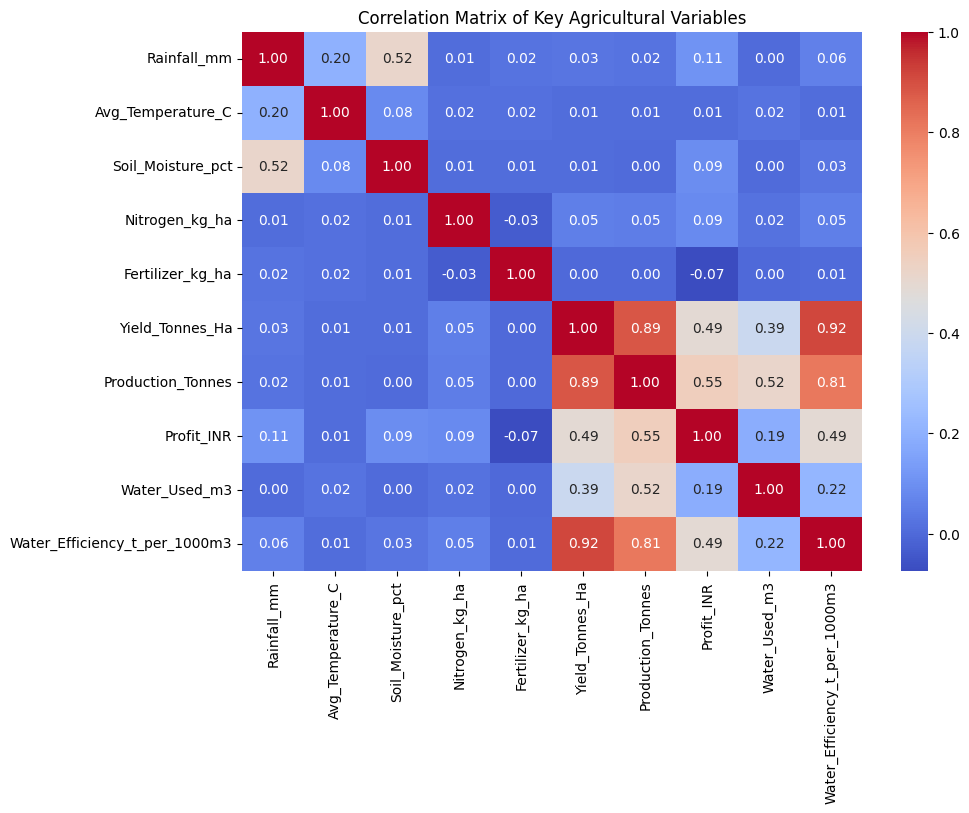

In [48]:
plt.figure(figsize=(10,7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Matrix of Key Agricultural Variables")
plt.show()

# **Additional Student-Driven Analysis**

# **Crop vs Profit**
Calculate average profit by crop

In [49]:
crop_profit = df.groupby("Crop")["Profit_INR"].mean().sort_values(ascending=False)

print(crop_profit)

Crop
Sugarcane    817187.986885
Chilli       750878.342233
Cotton       124546.915354
Groundnut     44858.120283
Pulses        -4238.052419
Maize        -83978.326679
Rice        -102213.504348
Wheat       -123398.337134
Name: Profit_INR, dtype: float64


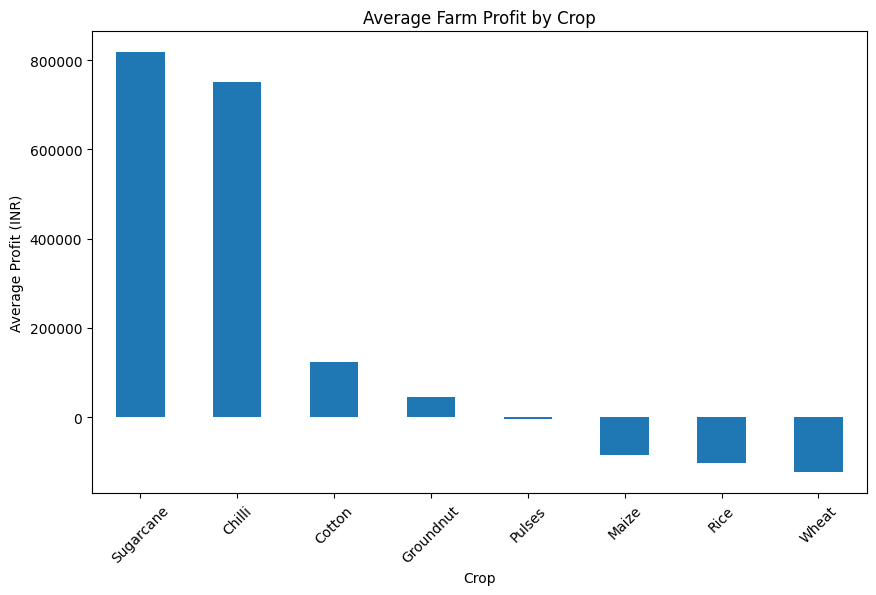

In [50]:
plt.figure(figsize=(10,6))

crop_profit.plot(kind="bar")

plt.title("Average Farm Profit by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45)

plt.show()

Sugarcane records the highest average profit, followed by Chilli. Pulses has a slightly negative average profit, while Maize, Rice and Wheat show larger average losses. This indicates substantial variation in profitability across crop types.

# **State-wise Yield**

In [51]:
state_yield = df.groupby("State")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

print(state_yield)

State
Punjab            6.121116
Karnataka         5.734493
Gujarat           5.699586
Telangana         5.076810
Maharashtra       5.030333
Madhya Pradesh    5.029654
Tamil Nadu        4.901247
Andhra Pradesh    4.650781
Name: Yield_Tonnes_Ha, dtype: float64


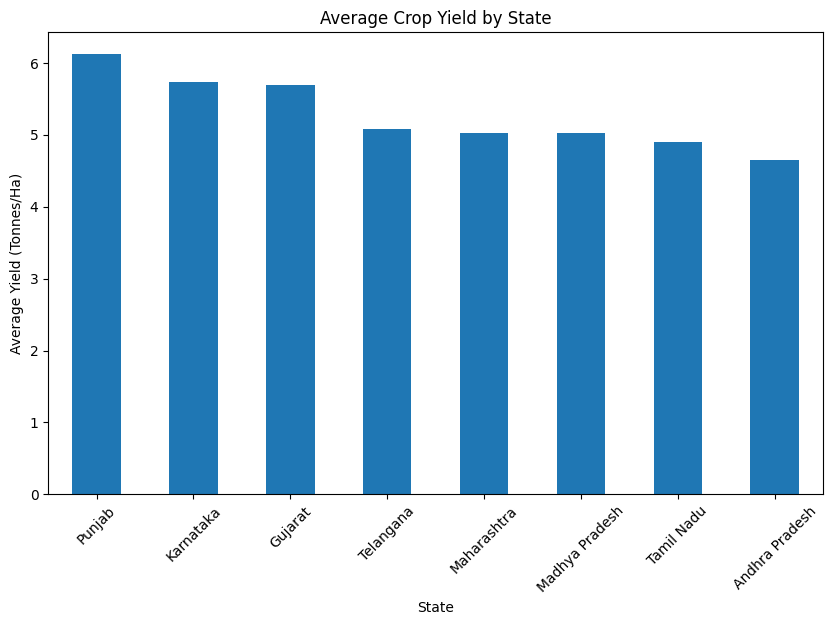

In [52]:
plt.figure(figsize=(10,6))

state_yield.plot(kind="bar")

plt.title("Average Crop Yield by State")
plt.xlabel("State")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)

plt.show()

Punjab has the highest average crop yield among the states at approximately 6.12 tonnes/ha, while Andhra Pradesh has the lowest at approximately 4.66 tonnes/ha. The results indicate geographical variation in agricultural yield within the dataset.

# **Season vs Water Efficiency**

In [53]:
season_efficiency = df.groupby("Season")[
    "Water_Efficiency_t_per_1000m3"
].mean().sort_values(ascending=False)

print(season_efficiency)

Season
Kharif    5.891834
Rabi      5.186122
Zaid      4.413239
Name: Water_Efficiency_t_per_1000m3, dtype: float64


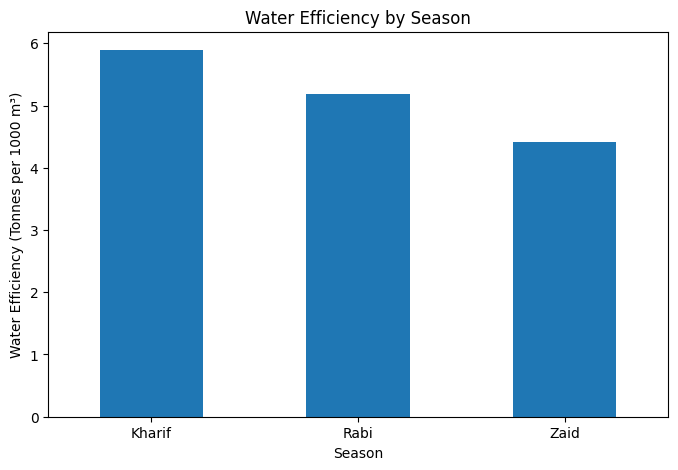

In [54]:
plt.figure(figsize=(8,5))

season_efficiency.plot(kind="bar")

plt.title("Water Efficiency by Season")
plt.xlabel("Season")
plt.ylabel("Water Efficiency (Tonnes per 1000 m³)")
plt.xticks(rotation=0)

plt.show()

Kharif has the highest average water efficiency at approximately 5.89 tonnes per 1000 m³, followed by Rabi at 5.19. Zaid has the lowest average efficiency at approximately 4.41.

# **Seasonal Performance Summary**

In [55]:
season_summary = df.groupby("Season").agg({
    "Yield_Tonnes_Ha": "mean",
    "Profit_INR": "mean",
    "Water_Used_m3": "mean",
    "Water_Efficiency_t_per_1000m3": "mean"
})

season_summary.columns = [
    "Average Yield",
    "Average Profit",
    "Average Water Used",
    "Average Water Efficiency"
]

print(season_summary.round(2))

        Average Yield  Average Profit  Average Water Used  \
Season                                                      
Kharif           5.64       178914.65             6102.20   
Rabi             5.08        87689.47             5846.99   
Zaid             4.67       -24804.82             6419.89   

        Average Water Efficiency  
Season                            
Kharif                      5.89  
Rabi                        5.19  
Zaid                        4.41  


# **What percentage of farms are actually profitable in each season?**

In [56]:
season_profitability = (
    df.groupby("Season")["Profit_INR"]
    .apply(lambda x: (x > 0).mean() * 100)
    .sort_values(ascending=False)
)

print(season_profitability.round(2))

Season
Kharif    57.79
Rabi      48.86
Zaid      35.52
Name: Profit_INR, dtype: float64


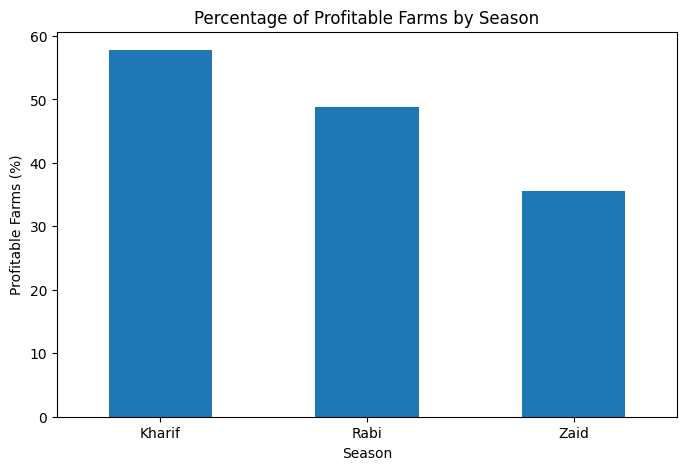

In [57]:
plt.figure(figsize=(8,5))

season_profitability.plot(kind="bar")

plt.title("Percentage of Profitable Farms by Season")
plt.xlabel("Season")
plt.ylabel("Profitable Farms (%)")
plt.xticks(rotation=0)

plt.show()

### **Limitations**

1. The analysis is based on the available dataset and may not represent all agricultural regions or farming conditions.

2. The dataset contains potential outliers in variables such as yield, profit and water usage. These observations were retained because they may represent genuine differences rather than data errors.

3. Correlation analysis identifies relationships between variables but does not establish cause-and-effect relationships.

4. Some variables, such as production and water efficiency, are mathematically related to yield and water usage, so their strong correlations should be interpreted carefully.

5. The analysis is based on historical/observed records and does not account for all external factors such as changing market conditions, farmer decisions or unexpected environmental events.

### **Conclusion**

This project analyzed 4,000 agricultural records across different crops, seasons, irrigation methods and states. The analysis examined crop yield, profitability, water usage and water efficiency using descriptive statistics and data visualization techniques.

The results showed substantial differences in agricultural performance across seasons, crops, irrigation methods and states. Kharif demonstrated the strongest overall performance in terms of average yield, profit and water efficiency, while Zaid showed comparatively weaker performance.

Sugarcane recorded the highest average yield and profitability among the crops, while Drip irrigation recorded the highest average profit among the irrigation methods. Rainfed farming showed the highest average water efficiency.

Overall, the analysis provides useful evidence for understanding seasonal agricultural performance and can support better decisions related to crop selection, irrigation management, resource utilization and seasonal planning.